In [1]:
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
from matplotlib.patches import Patch

plt.rcParams['figure.dpi'] = 300

In [2]:
def get_number_pocket_pairs(df):
    return len(set(tuple(sorted([i, j])) for i, j in zip(df['Pocket1'], df['Pocket2'])))

def get_number_protein_pairs(df):
    return len(set(tuple(sorted([i, j])) for i, j in zip(df['Protein1'], df['Protein2'])))

In [3]:
#####################################################
#####################################################
###############------ PHASE 1 ------#################
#####################################################
#####################################################

In [4]:
###########  PAIRS  ###########

In [5]:
ALL_RESULTS_PAIRS = pd.read_csv("../processed/protein_prioritization/pairs.tsv", sep='\t', low_memory=False)
ALL_RESULTS_PAIRS["InterPro-Pocket1"] = ALL_RESULTS_PAIRS["InterPro-Pocket1"].fillna("").astype(str)
ALL_RESULTS_PAIRS["InterPro-Pocket2"] = ALL_RESULTS_PAIRS["InterPro-Pocket2"].fillna("").astype(str)

proteins = sorted(set(ALL_RESULTS_PAIRS['Protein1']).union(set(ALL_RESULTS_PAIRS['Protein2'])))

In [6]:
ALL_RESULTS_PAIRS

,Protein1,Pocket1,InterPro-Pocket1,Protein2,Pocket2,InterPro-Pocket2,PocketVec distance,Protein RMSD,Protein SEQ ID (NW),Protein SEQ ID (CO),Dist PDB 1,Dist PDB 2,Dist Alphafill 1,Dist AlphaFill 2,P2Rank score 1,P2Rank score 2
0,P9WFT5,alphafold3_P9WFT5_model_2_pocket_2,Anticodon Binding Domain;Catalytic Domain (ATP...,P9WFU3,alphafold2_P9WFU3_model_0_pocket_1,,0.114,4.39,35.3659,20.40,NaN,NaN,19.860,1.487,7.45,34.45
1,P9WFT1,alphafold2_P9WFT1_model_0_pocket_2,Catalytic Domain (ATP Binding Site),P9WFU5,alphafold3_P9WFU5_model_2_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,0.117,18.21,29.0055,12.29,NaN,NaN,10.547,0.762,5.96,17.36
2,P9WFS9,chai1_P9WFS9_model_4_pocket_5,Catalytic Domain (ATP Binding Site);Editing Do...,P9WFV3,alphafold3_P9WFV3_model_4_pocket_2,Catalytic Domain (ATP Binding Site);Editing Do...,0.118,2.60,30.8422,25.15,NaN,NaN,0.383,4.391,9.76,20.01
3,P9WFU5,alphafold3_P9WFU5_model_2_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFV1,alphafold2_P9WFV1_model_0_pocket_4,Catalytic Domain (ATP Binding Site),0.121,1.97,32.9167,26.00,NaN,NaN,0.762,15.104,17.36,5.56
4,P9WFV7,swissmodel_P9WFV7_model_1_pocket_2,Anticodon Binding Domain,P9WFW5,chai1_P9WFW5_model_4_pocket_2,Catalytic Domain (ATP Binding Site);Other too ...,0.121,17.16,25.0000,12.75,NaN,NaN,24.070,12.217,3.70,4.69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,P9WFT5,chai1_P9WFT5_model_3_pocket_2,Anticodon Binding Domain;Catalytic Domain (ATP...,P9WFW1,swissmodel_P9WFW1_model_0_pocket_3,Catalytic Domain (ATP Binding Site),0.348,15.29,26.3736,11.64,NaN,NaN,20.842,4.442,6.47,5.31
32557,P9WFT3,alphafold3_P9WFT3_model_0_pocket_1,Catalytic Domain (ATP Binding Site),P9WFT5,alphafold3_P9WFT5_model_1_pocket_2,Anticodon Binding Domain;Catalytic Domain (ATP...,0.349,5.84,29.5732,8.57,NaN,NaN,0.414,20.690,10.19,5.66
32558,P9WFT5,alphafold3_P9WFT5_model_1_pocket_2,Anticodon Binding Domain;Catalytic Domain (ATP...,P9WFW1,swissmodel_P9WFW1_model_0_pocket_3,Catalytic Domain (ATP Binding Site),0.367,15.74,26.3736,11.64,NaN,NaN,20.690,4.442,5.66,5.31
32559,P9WFT5,chai1_P9WFT5_model_0_pocket_3,Anticodon Binding Domain;Catalytic Domain (ATP...,P9WFW1,swissmodel_P9WFW1_model_0_pocket_3,Catalytic Domain (ATP Binding Site),0.368,14.82,26.3736,11.64,NaN,NaN,22.371,4.442,8.72,5.31


In [7]:
RMSD_CUT_OFF = 10
SEQID_CUT_OFF = 35

In [8]:
# CATALYTIC COUNTS
CATALYTIC_COUNTS = []
for i,j in zip(ALL_RESULTS_PAIRS['InterPro-Pocket1'], ALL_RESULTS_PAIRS['InterPro-Pocket2']):
    counts = []
    for interpro in [i,j]:
        if "Catalytic Domain (ATP Binding Site)" in interpro:
            counts.append(1)
        else:
            counts.append(0)
    CATALYTIC_COUNTS.append(sum(counts))
ALL_RESULTS_PAIRS['catalytic_counts'] = CATALYTIC_COUNTS


# GLOBAL SIMILARITY
GLOBAL_SIMILARITY = []
for seqid, rmsd in zip(ALL_RESULTS_PAIRS['Protein SEQ ID (NW)'], ALL_RESULTS_PAIRS['Protein RMSD']):
    counts = []
    if seqid > SEQID_CUT_OFF and rmsd < RMSD_CUT_OFF:
        counts.append(1)
    else:
        counts.append(0)
    GLOBAL_SIMILARITY.append(sum(counts))
ALL_RESULTS_PAIRS['global_similarity'] = GLOBAL_SIMILARITY

In [9]:
TOTAL = []
PROTEIN_TO_OCCURRENCES_ALL = {i: {} for i in proteins}

GS, CAT = 0, 0
COND = (ALL_RESULTS_PAIRS['global_similarity'] == GS) & (ALL_RESULTS_PAIRS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_PAIRS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 1
COND = (ALL_RESULTS_PAIRS['global_similarity'] == GS) & (ALL_RESULTS_PAIRS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_PAIRS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 2
COND = (ALL_RESULTS_PAIRS['global_similarity'] == GS) & (ALL_RESULTS_PAIRS['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_PAIRS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 0
COND = (ALL_RESULTS_PAIRS['global_similarity'] == GS) & (ALL_RESULTS_PAIRS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_PAIRS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 1
COND = (ALL_RESULTS_PAIRS['global_similarity'] == GS) & (ALL_RESULTS_PAIRS['catalytic_counts'] == CAT)
COND = ALL_RESULTS_PAIRS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 2
COND = (ALL_RESULTS_PAIRS['global_similarity'] == GS) & (ALL_RESULTS_PAIRS['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_PAIRS[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_ALL[protein][(GS, CAT)] = counter[protein]

GS 0 -- CAT 0 -- 4,073[55]
GS 0 -- CAT 1 -- 15,368[136]
GS 0 -- CAT 2 -- 12,365[78]
GS 1 -- CAT 0 -- 53[2]
GS 1 -- CAT 1 -- 698[4]
GS 1 -- CAT 2 -- 4[1]


In [10]:
sum(TOTAL)

32561

In [22]:
ALL_RESULTS_PAIRS_POCKETVEC_017 = ALL_RESULTS_PAIRS[(ALL_RESULTS_PAIRS['PocketVec distance'] < 0.17)].reset_index(drop=True)

# Load protein to gene mapping
protein_to_gene = pd.read_csv("../data/mtb_trna_synthetases_bosch_2021_fig5_annotated.csv")
protein_to_gene = {i: j for i,j in zip(protein_to_gene['uniprot_ac'], protein_to_gene['gene_name_in_bosch_2021'])}

# Add mapping
ALL_RESULTS_PAIRS_POCKETVEC_017['Gene1'] = [protein_to_gene[i] for i in ALL_RESULTS_PAIRS_POCKETVEC_017['Protein1']]
ALL_RESULTS_PAIRS_POCKETVEC_017['Gene2'] = [protein_to_gene[i] for i in ALL_RESULTS_PAIRS_POCKETVEC_017['Protein2']]

# Add links to uniprot
ALL_RESULTS_PAIRS_POCKETVEC_017['Link_Protein1'] = [f"https://www.uniprot.org/uniprotkb/{i}/entry" for i in ALL_RESULTS_PAIRS_POCKETVEC_017['Protein1']]
ALL_RESULTS_PAIRS_POCKETVEC_017['Link_Protein2'] = [f"https://www.uniprot.org/uniprotkb/{i}/entry" for i in ALL_RESULTS_PAIRS_POCKETVEC_017['Protein2']]


# Save results
ALL_RESULTS_PAIRS_POCKETVEC_017.to_csv("../processed/protein_prioritization/pairs_filtered.tsv", sep='\t', index=False)

In [20]:
ALL_RESULTS_PAIRS_POCKETVEC_017

,Protein1,Pocket1,InterPro-Pocket1,Protein2,Pocket2,InterPro-Pocket2,PocketVec distance,Protein RMSD,Protein SEQ ID (NW),Protein SEQ ID (CO),Dist PDB 1,Dist PDB 2,Dist Alphafill 1,Dist AlphaFill 2,P2Rank score 1,P2Rank score 2,catalytic_counts,global_similarity,Gene1,Gene2
0,P9WFT5,alphafold3_P9WFT5_model_2_pocket_2,Anticodon Binding Domain;Catalytic Domain (ATP...,P9WFU3,alphafold2_P9WFU3_model_0_pocket_1,,0.114,4.39,35.3659,20.40,NaN,NaN,19.860,1.487,7.45,34.45,1,1,thrS,pheS
1,P9WFT1,alphafold2_P9WFT1_model_0_pocket_2,Catalytic Domain (ATP Binding Site),P9WFU5,alphafold3_P9WFU5_model_2_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,0.117,18.21,29.0055,12.29,NaN,NaN,10.547,0.762,5.96,17.36,2,0,tyrS,metS
2,P9WFS9,chai1_P9WFS9_model_4_pocket_5,Catalytic Domain (ATP Binding Site);Editing Do...,P9WFV3,alphafold3_P9WFV3_model_4_pocket_2,Catalytic Domain (ATP Binding Site);Editing Do...,0.118,2.60,30.8422,25.15,NaN,NaN,0.383,4.391,9.76,20.01,2,0,valS,ileS
3,P9WFU5,alphafold3_P9WFU5_model_2_pocket_1,Catalytic Domain (ATP Binding Site);Other too ...,P9WFV1,alphafold2_P9WFV1_model_0_pocket_4,Catalytic Domain (ATP Binding Site),0.121,1.97,32.9167,26.00,NaN,NaN,0.762,15.104,17.36,5.56,2,0,metS,leuS
4,P9WFV7,swissmodel_P9WFV7_model_1_pocket_2,Anticodon Binding Domain,P9WFW5,chai1_P9WFW5_model_4_pocket_2,Catalytic Domain (ATP Binding Site);Other too ...,0.121,17.16,25.0000,12.75,NaN,NaN,24.070,12.217,3.70,4.69,1,0,glyS,argS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1476,P9WFS9,alphafold3_P9WFS9_model_4_pocket_2,Catalytic Domain (ATP Binding Site);Editing Do...,P9WFT9,swissmodel_P9WFT9_model_0_pocket_2,Anticodon Binding Domain,0.169,11.13,27.3852,13.78,NaN,NaN,1.588,14.631,10.46,3.06,1,0,valS,proS
1477,P9WFS9,alphafold3_P9WFS9_model_4_pocket_3,Catalytic Domain (ATP Binding Site),P9WFW5,chai1_P9WFW5_model_4_pocket_2,Catalytic Domain (ATP Binding Site);Other too ...,0.169,5.65,29.6296,21.60,NaN,NaN,10.105,12.217,7.70,4.69,2,0,valS,argS
1478,P9WFT9,chai1_P9WFT9_model_0_pocket_2,Other too broad/unspecified functional entities,P9WFV5,alphafold2_P9WFV5_model_0_pocket_1,,0.169,2.53,30.6763,12.20,NaN,NaN,18.478,0.616,2.77,18.75,0,0,proS,hisS
1479,P9WFT1,alphafold3_P9WFT1_model_4_pocket_2,Catalytic Domain (ATP Binding Site),P9WFW7,swissmodel_P9WFW7_model_0_pocket_1,,0.169,18.89,31.6547,17.65,NaN,NaN,10.806,1.716,6.76,24.28,1,0,tyrS,alaS


In [14]:
len(ALL_RESULTS_PAIRS_POCKETVEC_017)

1481

In [15]:
TOTAL = []
PROTEIN_TO_OCCURRENCES_POCKETVEC_017 = {i: {} for i in proteins}

GS, CAT = 0, 0
COND = (ALL_RESULTS_PAIRS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_PAIRS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_PAIRS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 1
COND = (ALL_RESULTS_PAIRS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_PAIRS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_PAIRS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 2
COND = (ALL_RESULTS_PAIRS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_PAIRS_POCKETVEC_017['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_PAIRS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 0
COND = (ALL_RESULTS_PAIRS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_PAIRS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_PAIRS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 1
COND = (ALL_RESULTS_PAIRS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_PAIRS_POCKETVEC_017['catalytic_counts'] == CAT)
COND = ALL_RESULTS_PAIRS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 2
COND = (ALL_RESULTS_PAIRS_POCKETVEC_017['global_similarity'] == GS) & (ALL_RESULTS_PAIRS_POCKETVEC_017['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_PAIRS_POCKETVEC_017[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][(GS, CAT)] = counter[protein]

GS 0 -- CAT 0 -- 94[35]
GS 0 -- CAT 1 -- 574[105]
GS 0 -- CAT 2 -- 787[59]
GS 1 -- CAT 0 -- 3[2]
GS 1 -- CAT 1 -- 23[4]
GS 1 -- CAT 2 -- 0[0]


In [16]:
sum(TOTAL)

1481

In [17]:
ALL_RESULTS_PAIRS_POCKETVEC_014 = ALL_RESULTS_PAIRS[(ALL_RESULTS_PAIRS['PocketVec distance'] < 0.14)].reset_index(drop=True)

In [18]:
len(ALL_RESULTS_PAIRS_POCKETVEC_014)

96

In [19]:
TOTAL = []
PROTEIN_TO_OCCURRENCES_POCKETVEC_014 = {i: {} for i in proteins}

GS, CAT = 0, 0
COND = (ALL_RESULTS_PAIRS_POCKETVEC_014['global_similarity'] == GS) & (ALL_RESULTS_PAIRS_POCKETVEC_014['catalytic_counts'] == CAT)
COND = ALL_RESULTS_PAIRS_POCKETVEC_014[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_014[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 1
COND = (ALL_RESULTS_PAIRS_POCKETVEC_014['global_similarity'] == GS) & (ALL_RESULTS_PAIRS_POCKETVEC_014['catalytic_counts'] == CAT)
COND = ALL_RESULTS_PAIRS_POCKETVEC_014[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_014[protein][(GS, CAT)] = counter[protein]

GS, CAT = 0, 2
COND = (ALL_RESULTS_PAIRS_POCKETVEC_014['global_similarity'] == GS) & (ALL_RESULTS_PAIRS_POCKETVEC_014['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_PAIRS_POCKETVEC_014[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_014[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 0
COND = (ALL_RESULTS_PAIRS_POCKETVEC_014['global_similarity'] == GS) & (ALL_RESULTS_PAIRS_POCKETVEC_014['catalytic_counts'] == CAT)
COND = ALL_RESULTS_PAIRS_POCKETVEC_014[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_014[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 1
COND = (ALL_RESULTS_PAIRS_POCKETVEC_014['global_similarity'] == GS) & (ALL_RESULTS_PAIRS_POCKETVEC_014['catalytic_counts'] == CAT)
COND = ALL_RESULTS_PAIRS_POCKETVEC_014[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_014[protein][(GS, CAT)] = counter[protein]

GS, CAT = 1, 2
COND = (ALL_RESULTS_PAIRS_POCKETVEC_014['global_similarity'] == GS) & (ALL_RESULTS_PAIRS_POCKETVEC_014['catalytic_counts'] >= CAT)
COND = ALL_RESULTS_PAIRS_POCKETVEC_014[COND].reset_index(drop=True)
print(f"GS {GS} -- CAT {CAT} -- {get_number_pocket_pairs(COND):,}[{get_number_protein_pairs(COND)}]")
TOTAL.append(get_number_pocket_pairs(COND))
counter = Counter(COND['Protein1'].tolist() + COND['Protein2'].tolist())
for protein in proteins:
    PROTEIN_TO_OCCURRENCES_POCKETVEC_014[protein][(GS, CAT)] = counter[protein]

GS 0 -- CAT 0 -- 0[0]
GS 0 -- CAT 1 -- 26[20]
GS 0 -- CAT 2 -- 69[22]
GS 1 -- CAT 0 -- 0[0]
GS 1 -- CAT 1 -- 1[1]
GS 1 -- CAT 2 -- 0[0]


In [20]:
sum(TOTAL)

96

In [21]:
#####################################################
#####################################################
###############------ PHASE 2 ------#################
#####################################################
#####################################################

In [22]:
#####################################################
#####################################################
###############------ PHASE 3 ------#################
#####################################################
#####################################################

In [23]:
###########  PAIRS  ###########

In [24]:
ERSILIA_COLORS = {(0,0): '#BEE6B4', 
                  (0,1): '#FAD782', 
                  (0,2): '#FAA08B', 
                  (1,0): '#DC9FDC', 
                  (1,1): '#AA96FA', 
                  (1,2): '#8DC7FA'}

inds = sorted(ERSILIA_COLORS)

In [25]:
### ALL RESULTS ###

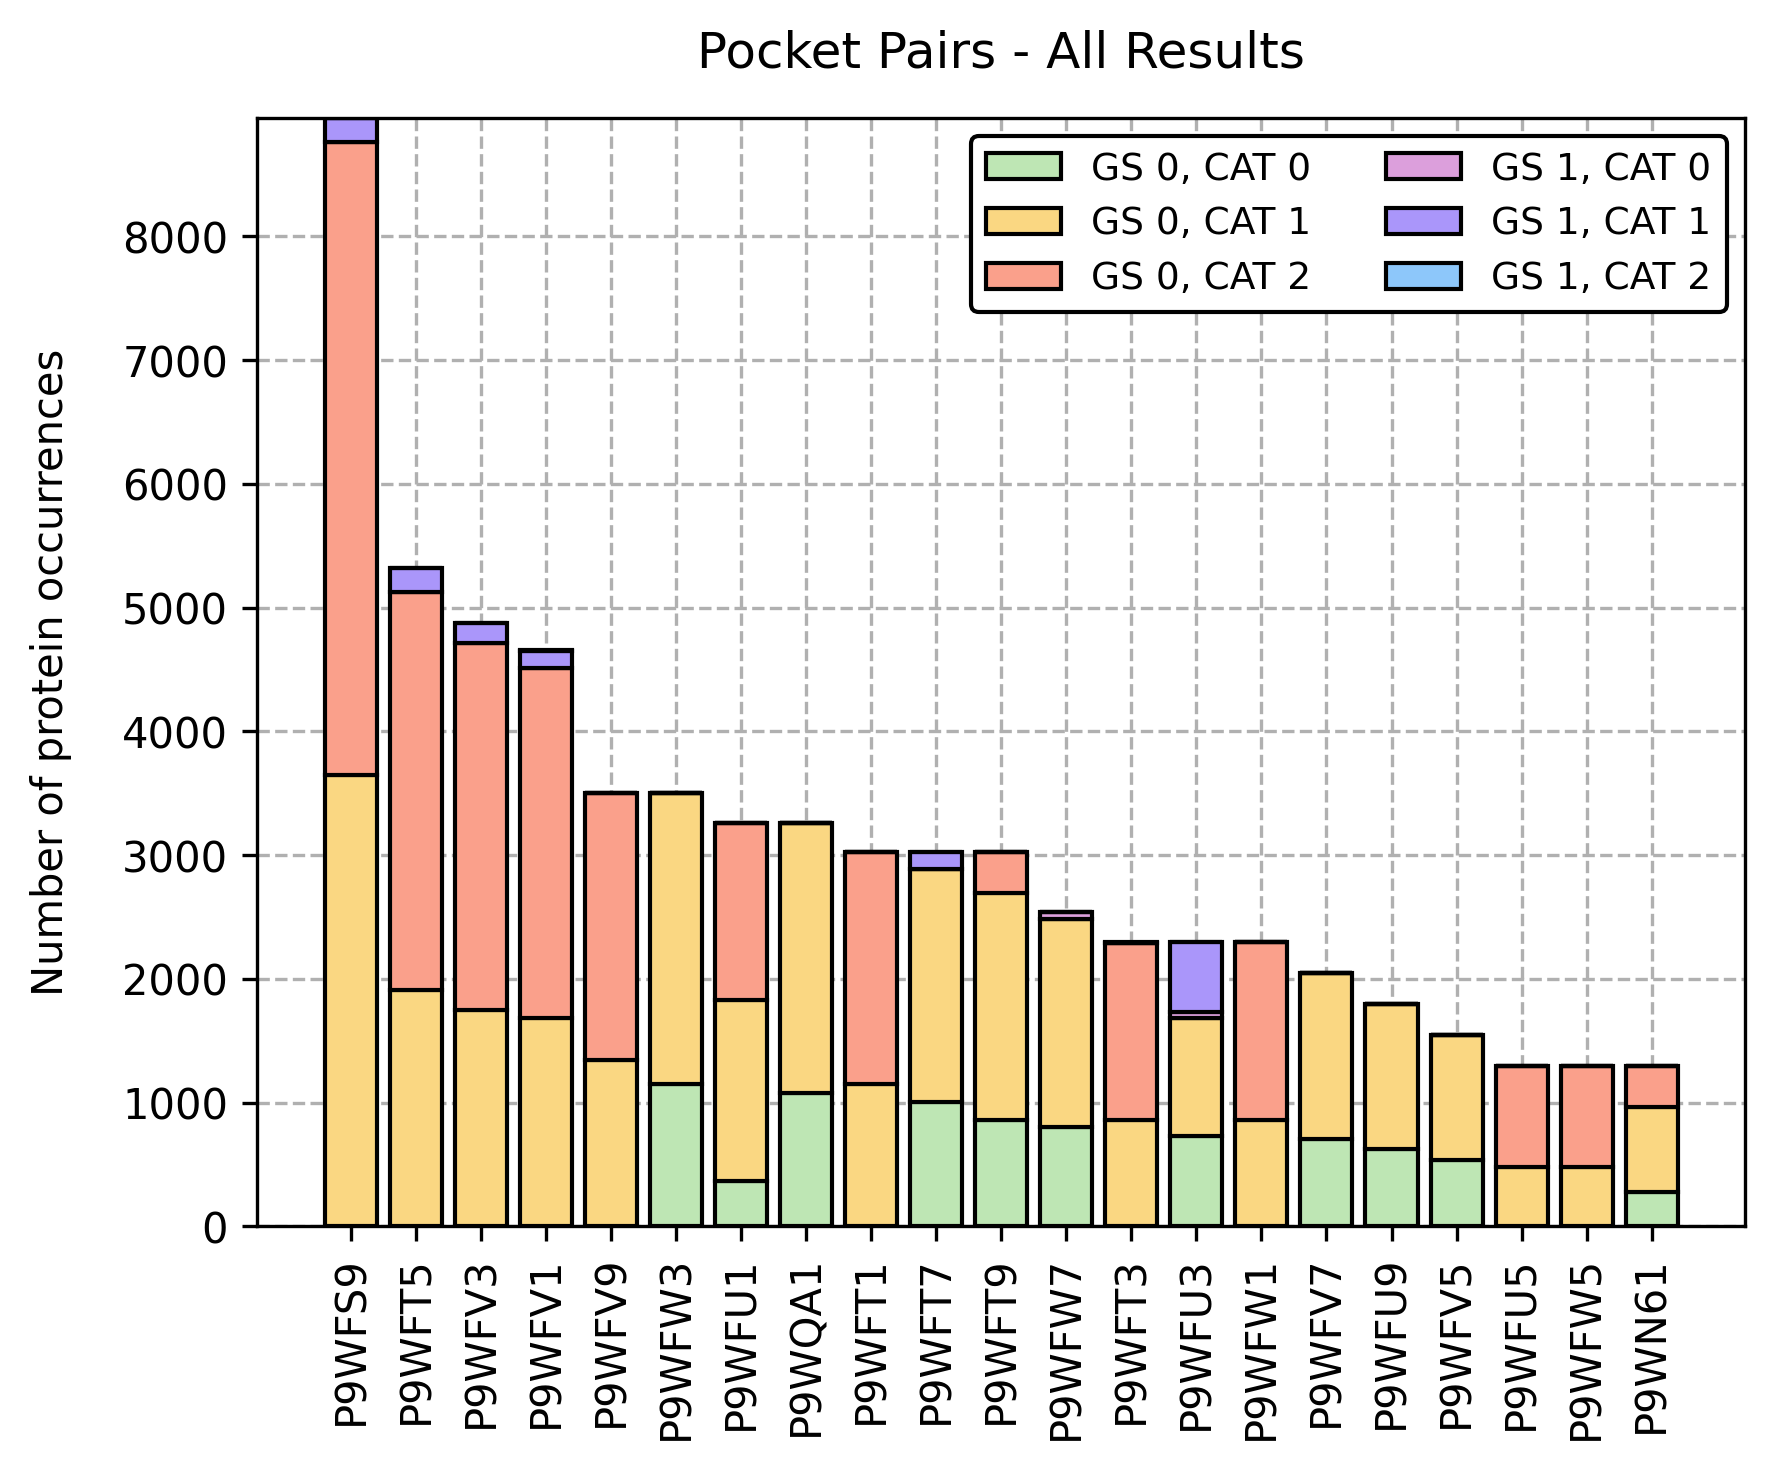

In [26]:
proteins = sorted(PROTEIN_TO_OCCURRENCES_ALL, key=lambda x: sum(PROTEIN_TO_OCCURRENCES_ALL[x].values()), reverse=True)

for c1, protein in enumerate(proteins):
    for c2, ind in enumerate(inds):
        bottom = sum([PROTEIN_TO_OCCURRENCES_ALL[protein][i] for i in inds if i < ind])
        if c1 == 0:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_ALL[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], 
                    edgecolor='black', linewidth=1, zorder=2, label=f"GS {ind[0]}, CAT {ind[1]}")
        else:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_ALL[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], edgecolor='black', linewidth=1, zorder=2) 

plt.title("Pocket Pairs - All Results", pad=12)
plt.ylabel('Number of protein occurrences', labelpad=12)
plt.xticks([i for i in range(len(proteins))], proteins, rotation=90)
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', ncols=2, prop={'size': 9})
plt.show()

In [27]:
sum([sum(PROTEIN_TO_OCCURRENCES_ALL[i].values()) for i in PROTEIN_TO_OCCURRENCES_ALL]) / 2

32561.0

In [28]:
### POCKETVEC < 0.17 ###

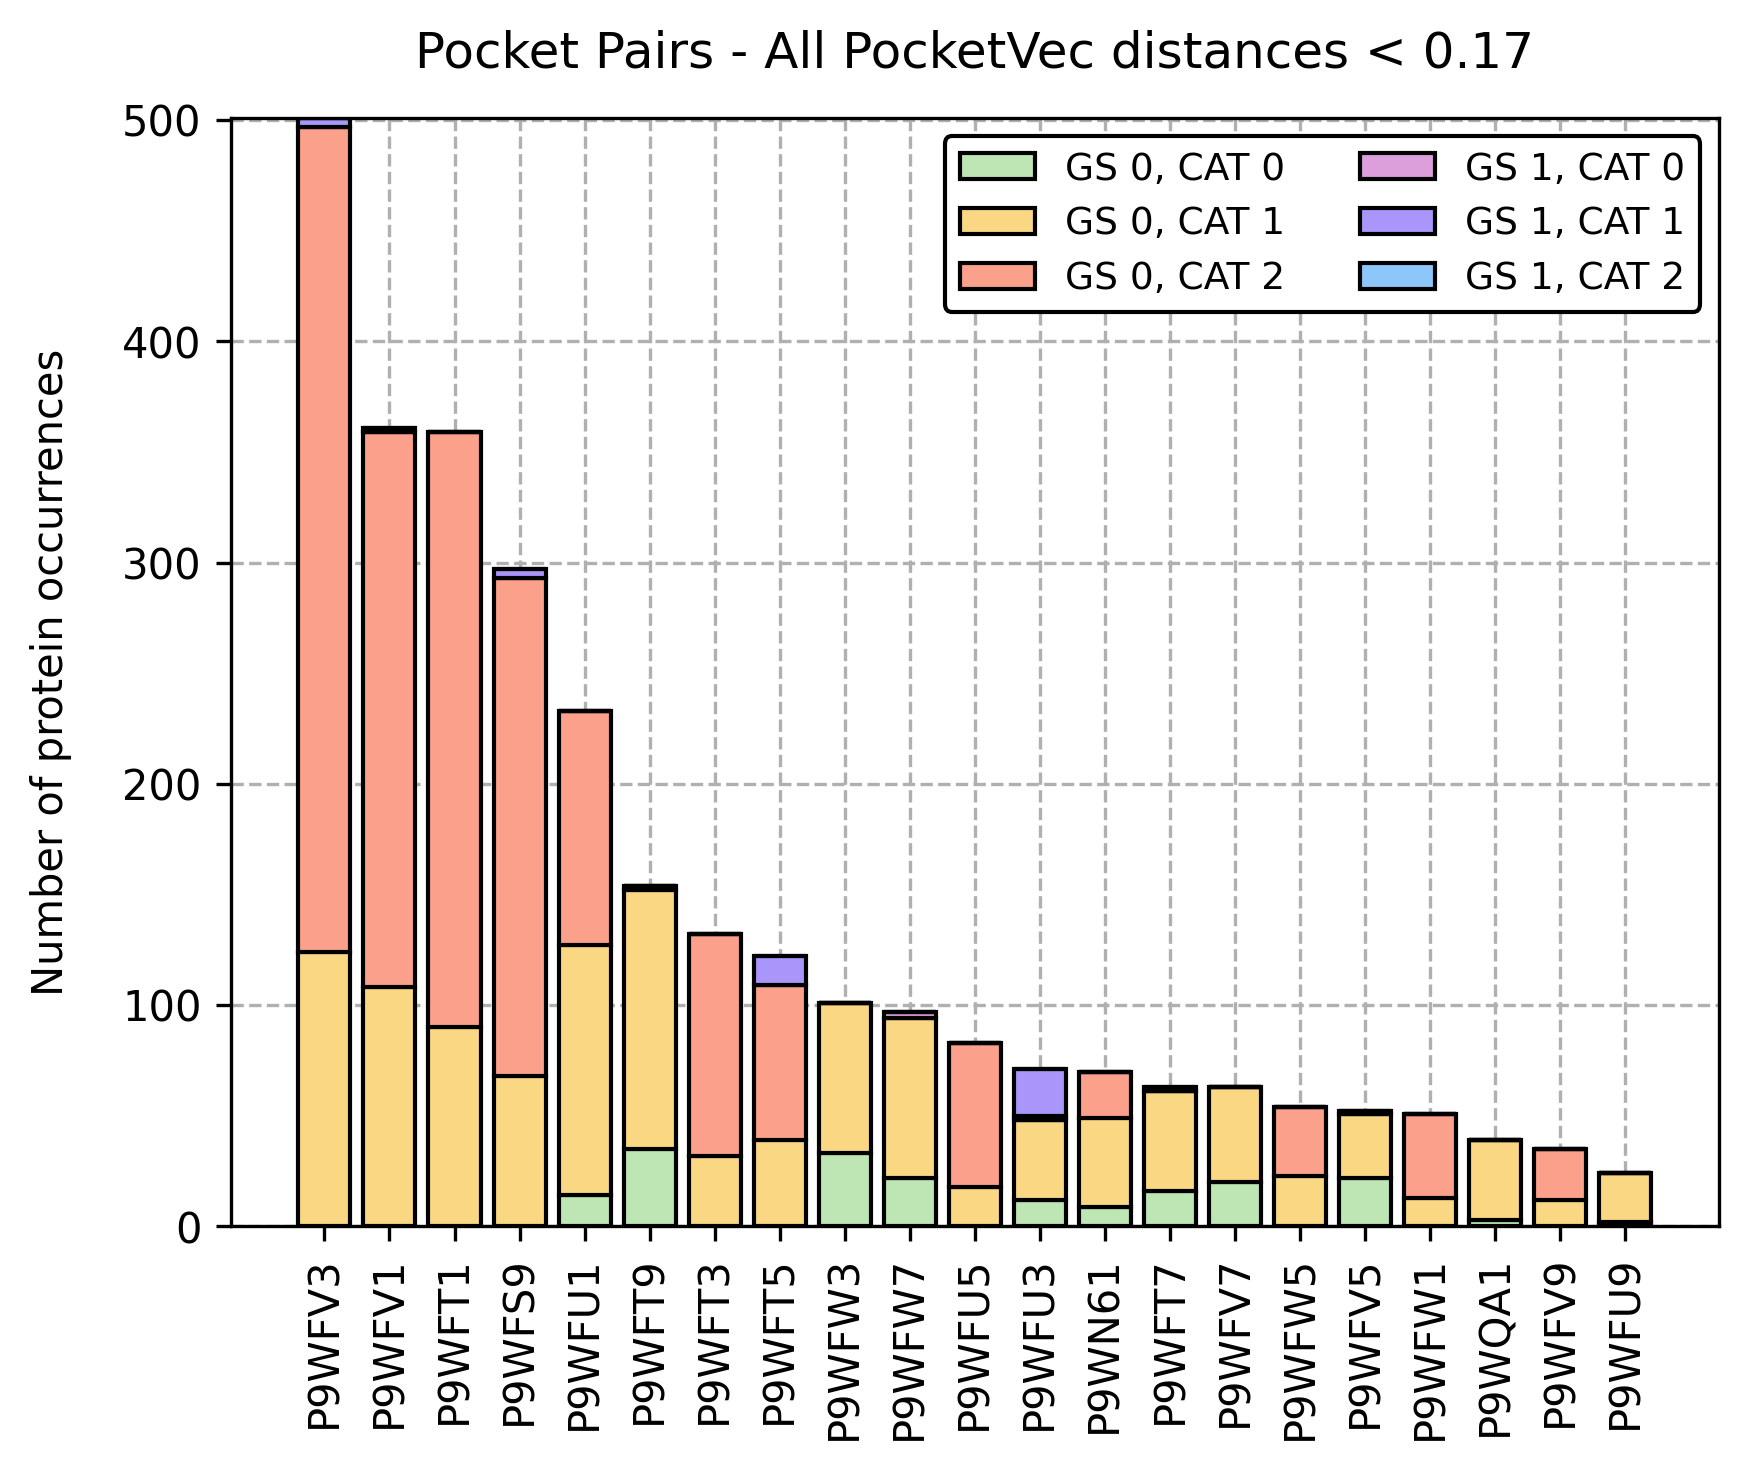

In [29]:
proteins = sorted(PROTEIN_TO_OCCURRENCES_POCKETVEC_017, key=lambda x: sum(PROTEIN_TO_OCCURRENCES_POCKETVEC_017[x].values()), reverse=True)

for c1, protein in enumerate(proteins):
    for c2, ind in enumerate(inds):
        bottom = sum([PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][i] for i in inds if i < ind])
        if c1 == 0:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], 
                    edgecolor='black', linewidth=1, zorder=2, label=f"GS {ind[0]}, CAT {ind[1]}")
        else:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_POCKETVEC_017[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], edgecolor='black', linewidth=1, zorder=2) 

plt.title("Pocket Pairs - All PocketVec distances < 0.17", pad=12)
plt.ylabel('Number of protein occurrences', labelpad=12)
plt.xticks([i for i in range(len(proteins))], proteins, rotation=90)
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', ncols=2, prop={'size': 9})
plt.show()

In [30]:
### POCKETVEC < 0.14 ###

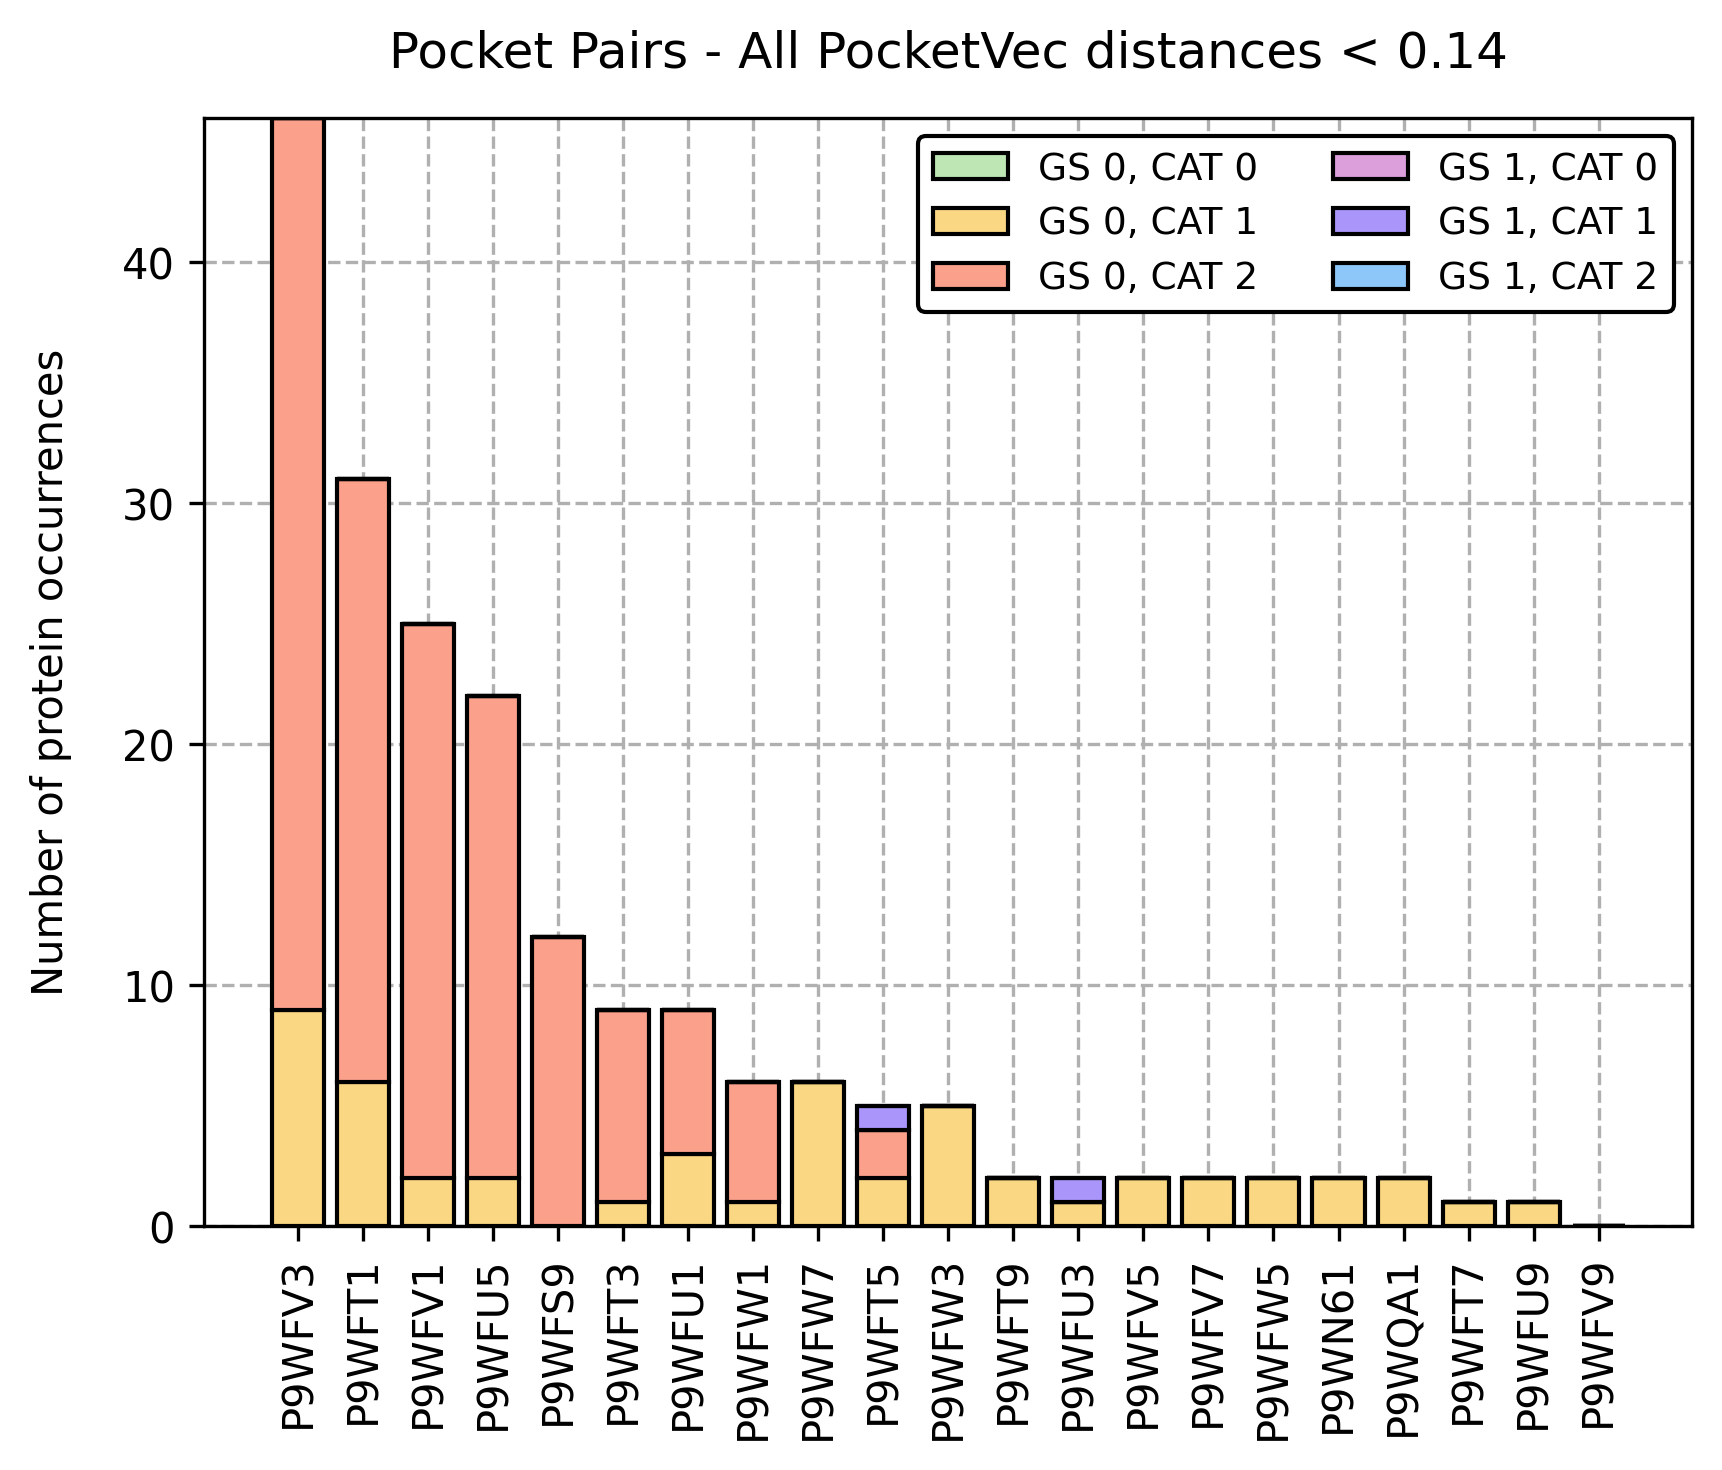

In [31]:
proteins = sorted(PROTEIN_TO_OCCURRENCES_POCKETVEC_014, key=lambda x: sum(PROTEIN_TO_OCCURRENCES_POCKETVEC_014[x].values()), reverse=True)

for c1, protein in enumerate(proteins):
    for c2, ind in enumerate(inds):
        bottom = sum([PROTEIN_TO_OCCURRENCES_POCKETVEC_014[protein][i] for i in inds if i < ind])
        if c1 == 0:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_POCKETVEC_014[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], 
                    edgecolor='black', linewidth=1, zorder=2, label=f"GS {ind[0]}, CAT {ind[1]}")
        else:
            plt.bar(c1, PROTEIN_TO_OCCURRENCES_POCKETVEC_014[protein][ind], bottom=bottom, color=ERSILIA_COLORS[ind], edgecolor='black', linewidth=1, zorder=2) 

plt.title("Pocket Pairs - All PocketVec distances < 0.14", pad=12)
plt.ylabel('Number of protein occurrences', labelpad=12)
plt.xticks([i for i in range(len(proteins))], proteins, rotation=90)
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', ncols=2, prop={'size': 9})
plt.show()

In [32]:
### NOW FROM THE DOMAIN PERSPECTIVE ... ###

In [33]:
ERSILIA_COLORS = ['#50285A', '#FAD782', '#FAA08B', '#DC9FDC', '#AA96FA', '#8DC7FA', '#BEE6B4', '#D2D2D2'][1:]

In [34]:
### ALL RESULTS ###

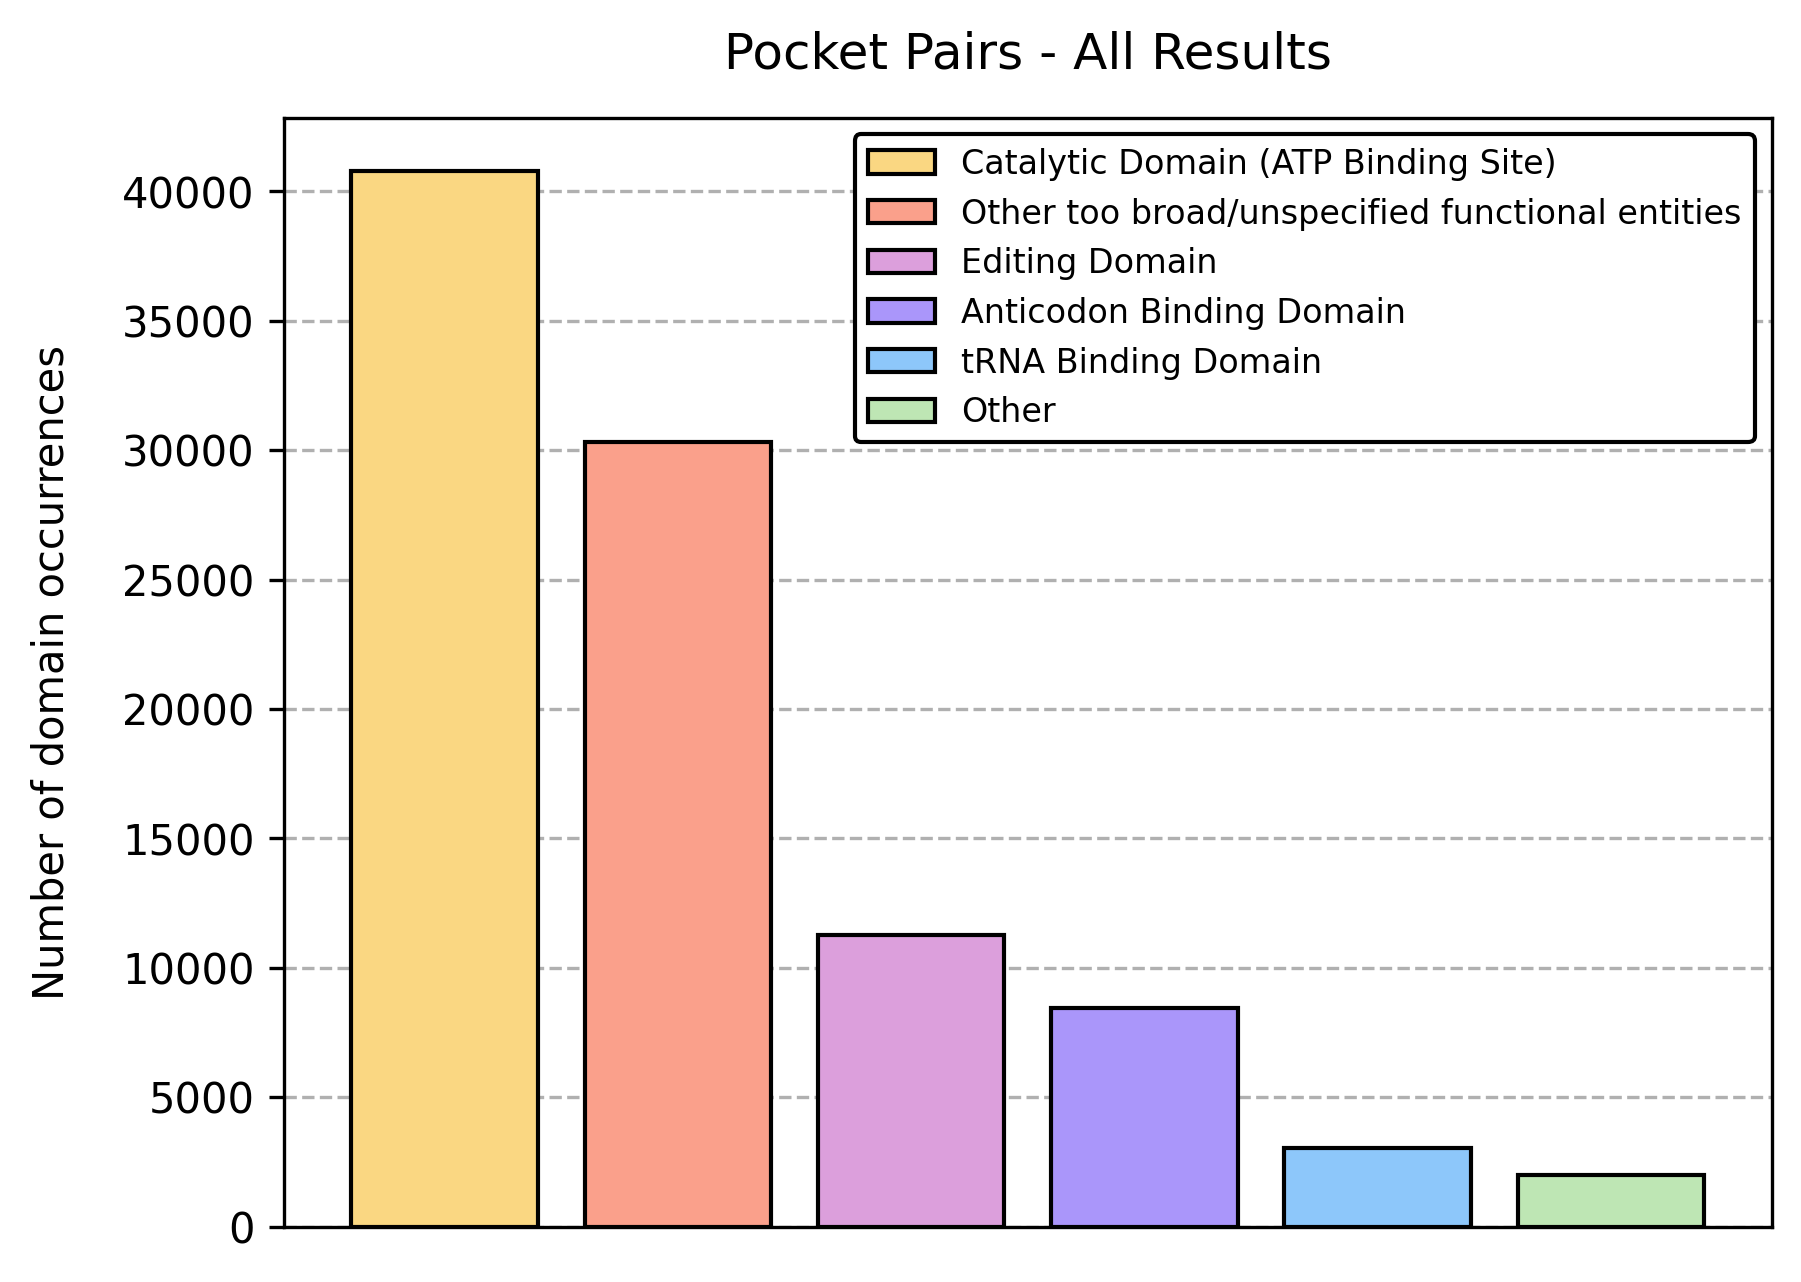

In [35]:
interpro_domains = ALL_RESULTS_PAIRS['InterPro-Pocket1'].tolist() + ALL_RESULTS_PAIRS['InterPro-Pocket2'].tolist()
interpro_domains = [j for i in interpro_domains for j in i.split(";") if j != ""]
interpro_domains = Counter(interpro_domains)

domains = sorted(interpro_domains, key = lambda x: interpro_domains[x], reverse=True)
for c1, domain in enumerate(domains):
    plt.bar(c1, interpro_domains[domain], color=ERSILIA_COLORS[c1], edgecolor='black', linewidth=1, zorder=2, label=domain)

plt.title("Pocket Pairs - All Results", pad=12)
plt.ylabel('Number of domain occurrences', labelpad=12)
plt.xticks([])
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 8})
plt.show()

In [36]:
### POCKETVEC < 0.17 ###

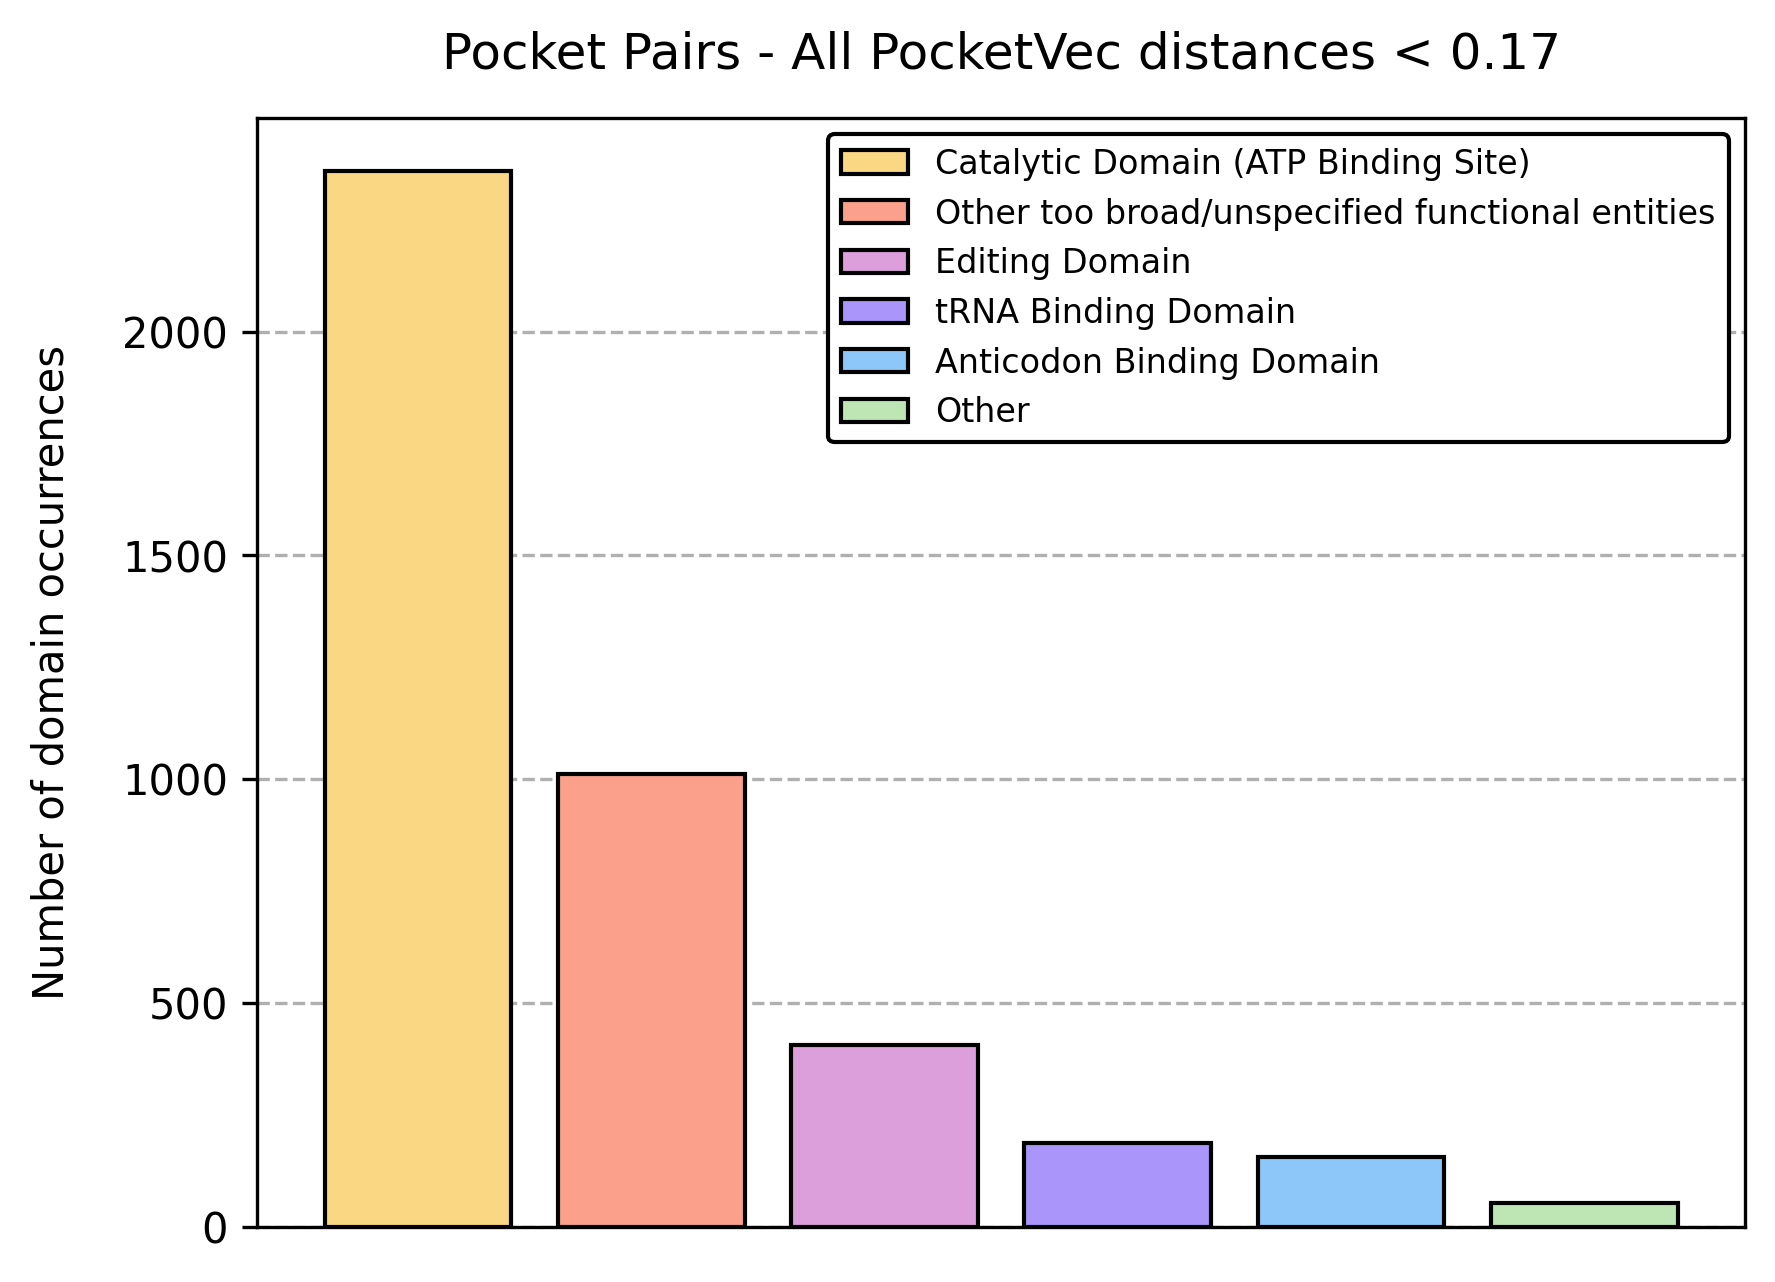

In [37]:
interpro_domains = ALL_RESULTS_PAIRS_POCKETVEC_017['InterPro-Pocket1'].tolist() + ALL_RESULTS_PAIRS_POCKETVEC_017['InterPro-Pocket1'].tolist()
interpro_domains = [j for i in interpro_domains for j in i.split(";") if j != ""]
interpro_domains = Counter(interpro_domains)

domains = sorted(interpro_domains, key = lambda x: interpro_domains[x], reverse=True)
for c1, domain in enumerate(domains):
    plt.bar(c1, interpro_domains[domain], color=ERSILIA_COLORS[c1], edgecolor='black', linewidth=1, zorder=2, label=domain)

plt.title("Pocket Pairs - All PocketVec distances < 0.17", pad=12)
plt.ylabel('Number of domain occurrences', labelpad=12)
plt.xticks([])
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 8})
plt.show()

In [38]:
### POCKETVEC < 0.14 ###

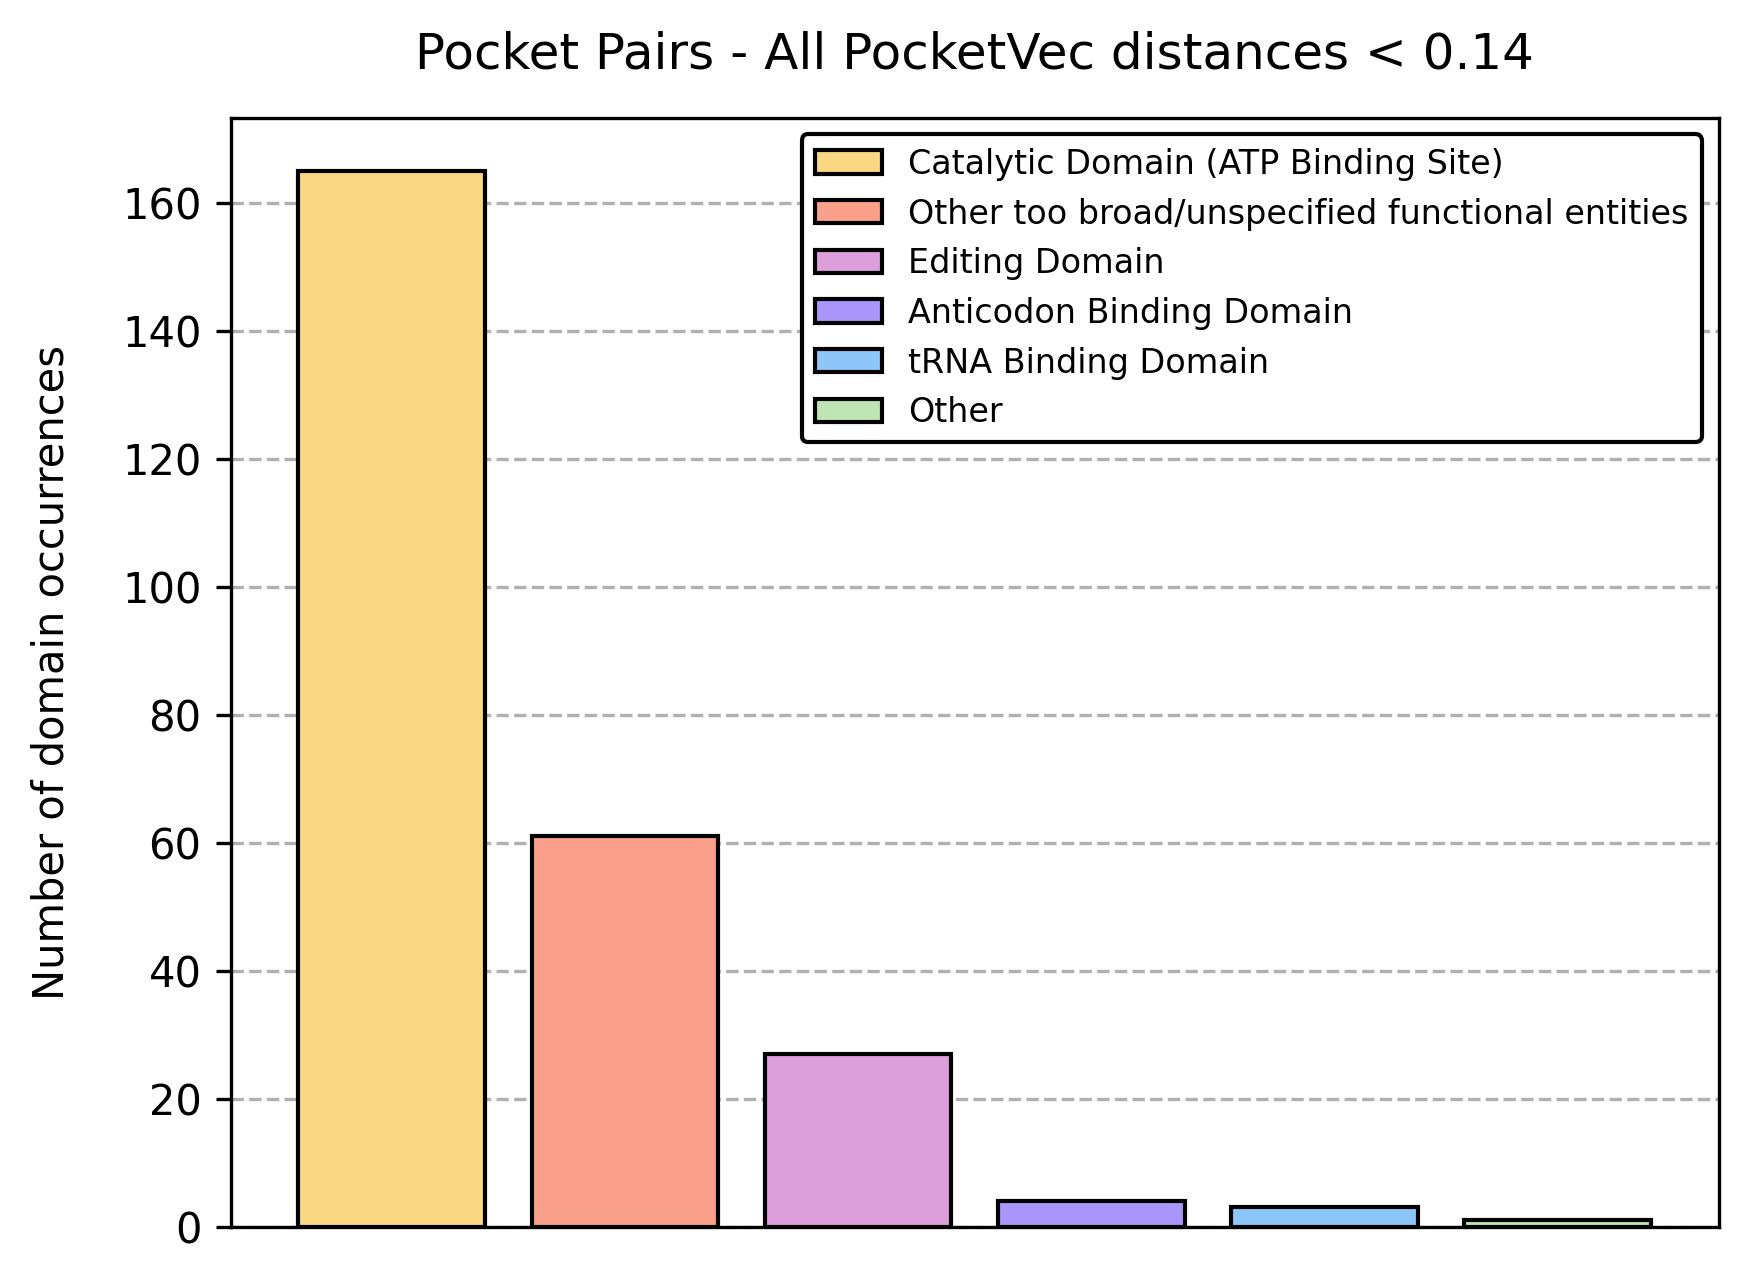

In [39]:
interpro_domains = ALL_RESULTS_PAIRS_POCKETVEC_014['InterPro-Pocket1'].tolist() + ALL_RESULTS_PAIRS_POCKETVEC_014['InterPro-Pocket2'].tolist()
interpro_domains = [j for i in interpro_domains for j in i.split(";") if j != ""]
interpro_domains = Counter(interpro_domains)

domains = sorted(interpro_domains, key = lambda x: interpro_domains[x], reverse=True)
for c1, domain in enumerate(domains):
    plt.bar(c1, interpro_domains[domain], color=ERSILIA_COLORS[c1], edgecolor='black', linewidth=1, zorder=2, label=domain)

plt.title("Pocket Pairs - All PocketVec distances < 0.14", pad=12)
plt.ylabel('Number of domain occurrences', labelpad=12)
plt.xticks([])
plt.grid(linestyle='--')
plt.legend(loc='upper right', framealpha=1, edgecolor='k', prop={'size': 8})
plt.show()

In [40]:
### NOW FROM THE DOMAIN/PROTEIN PERSPECTIVE ... ###

In [41]:
ERSILIA_COLORS = ['#50285A', '#FAD782', '#FAA08B', '#DC9FDC', '#AA96FA', '#8DC7FA', '#BEE6B4', '#D2D2D2'][1:]

cc_colors = {
            'A': ['#EA5A49', '#EE7B6D', '#F7BDB6'],
            'B': ['#B16BA8', '#C189B9', '#D0A6CB'],
            'C': ['#5A72B5', '#7B8EC4', '#9CAAD3'],
            'D': ['#7CAF2A', '#96BF55', '#B0CF7F'],
            'E': ['#F39426', '#F5A951', '#F8BF7D'],
            'Z': ['#000000', '#666666', '#999999']}

In [42]:
domains = ALL_RESULTS_PAIRS['InterPro-Pocket1'].tolist() + ALL_RESULTS_PAIRS['InterPro-Pocket2'].tolist()
domains = set([j for i in domains for j in i.split(";") if j != ""])
proteins = set(ALL_RESULTS_PAIRS['Protein1'].tolist() + ALL_RESULTS_PAIRS['Protein2'].tolist())

# ALL RESULTS
protein_to_domain_counts_ALL_RESULTS = {i: {j: 0 for j in domains} for i in proteins}
for protein in proteins:
    for domain in domains:
        protein_to_domain_counts_ALL_RESULTS[protein][domain] = len(ALL_RESULTS_PAIRS[(ALL_RESULTS_PAIRS['Protein1'] == protein) & 
                                                                                      (ALL_RESULTS_PAIRS['InterPro-Pocket1'].str.contains(domain, regex=False))])
        protein_to_domain_counts_ALL_RESULTS[protein][domain] += len(ALL_RESULTS_PAIRS[(ALL_RESULTS_PAIRS['Protein2'] == protein) & 
                                                                                       (ALL_RESULTS_PAIRS['InterPro-Pocket2'].str.contains(domain, regex=False))])
        
# POCKETVEC < 0.17
protein_to_domain_counts_POCKETVEC_017 = {i: {j: 0 for j in domains} for i in proteins}
for protein in proteins:
    for domain in domains:
        protein_to_domain_counts_POCKETVEC_017[protein][domain] = len(ALL_RESULTS_PAIRS_POCKETVEC_017[(ALL_RESULTS_PAIRS_POCKETVEC_017['Protein1'] == protein) & 
                                                                                      (ALL_RESULTS_PAIRS_POCKETVEC_017['InterPro-Pocket1'].str.contains(domain, regex=False))])
        protein_to_domain_counts_POCKETVEC_017[protein][domain] += len(ALL_RESULTS_PAIRS_POCKETVEC_017[(ALL_RESULTS_PAIRS_POCKETVEC_017['Protein2'] == protein) & 
                                                                                       (ALL_RESULTS_PAIRS_POCKETVEC_017['InterPro-Pocket2'].str.contains(domain, regex=False))])
# POCKETVEC < 0.14
protein_to_domain_counts_POCKETVEC_014 = {i: {j: 0 for j in domains} for i in proteins}
for protein in proteins:
    for domain in domains:
        protein_to_domain_counts_POCKETVEC_014[protein][domain] = len(ALL_RESULTS_PAIRS_POCKETVEC_014[(ALL_RESULTS_PAIRS_POCKETVEC_014['Protein1'] == protein) & 
                                                                                      (ALL_RESULTS_PAIRS_POCKETVEC_014['InterPro-Pocket1'].str.contains(domain, regex=False))])
        protein_to_domain_counts_POCKETVEC_014[protein][domain] += len(ALL_RESULTS_PAIRS_POCKETVEC_014[(ALL_RESULTS_PAIRS_POCKETVEC_014['Protein2'] == protein) & 
                                                                                       (ALL_RESULTS_PAIRS_POCKETVEC_014['InterPro-Pocket2'].str.contains(domain, regex=False))])

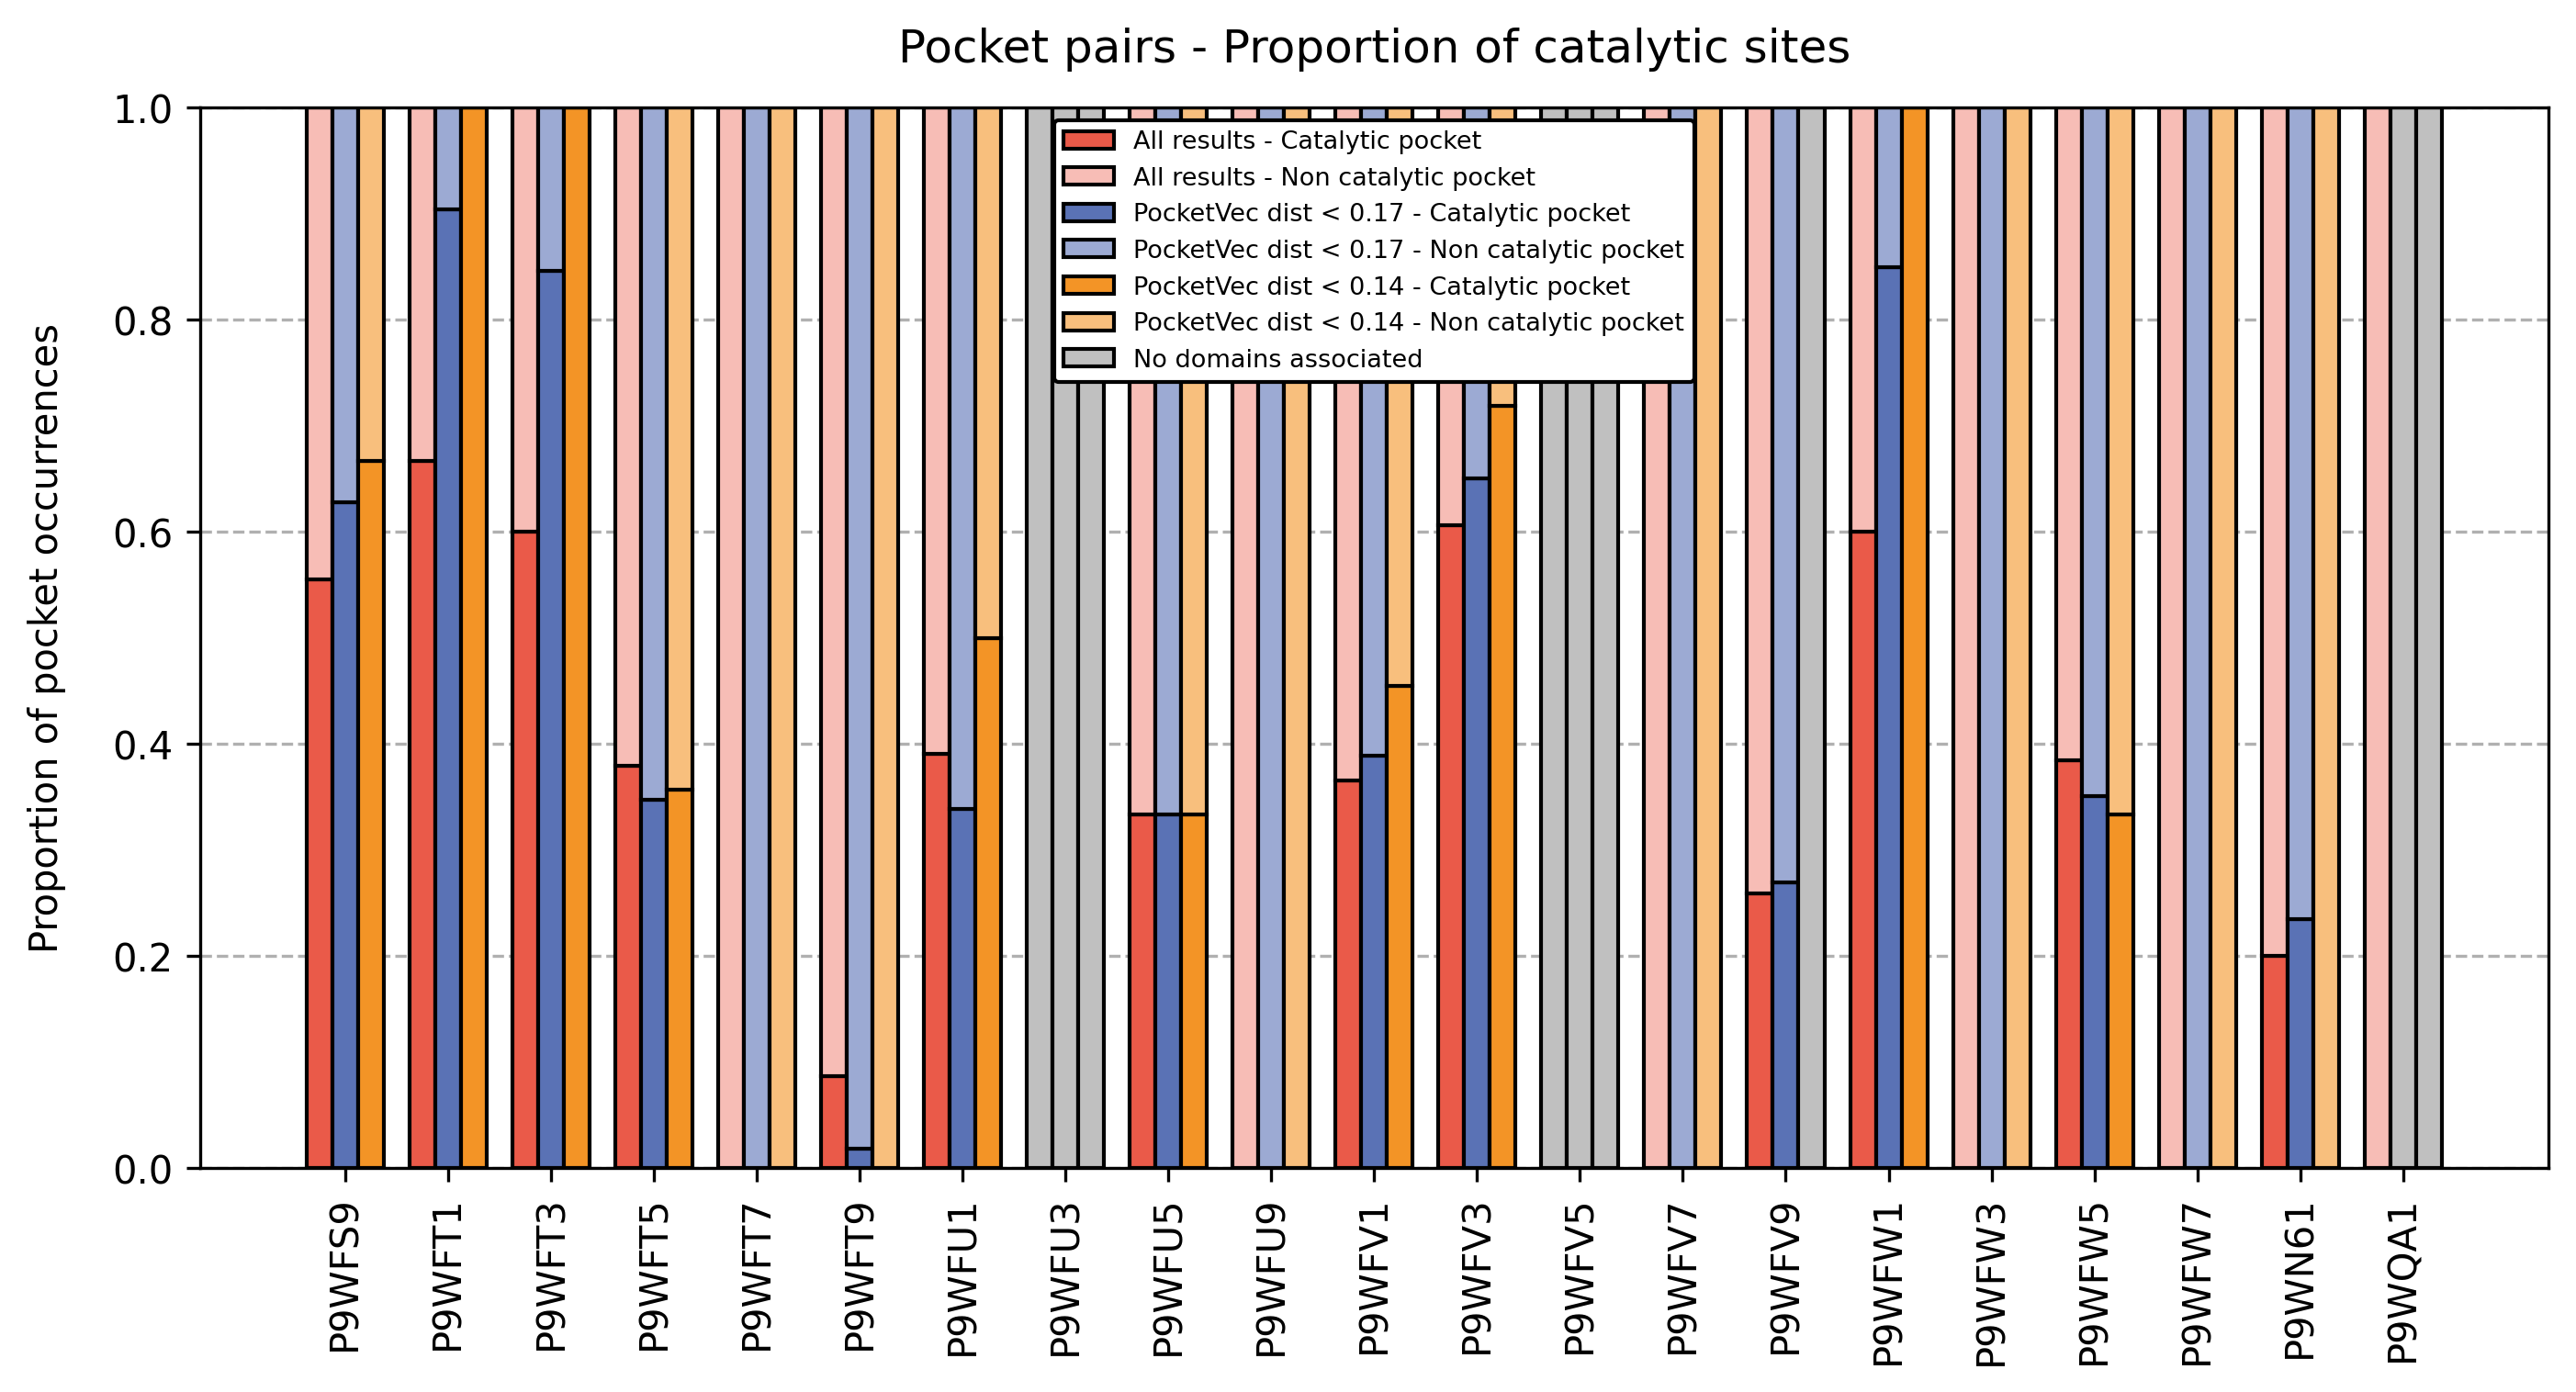

In [43]:
plt.figure(figsize=(11, 5))
plt.title("Pocket pairs - Proportion of catalytic sites", pad=12)

for c1, protein in enumerate(sorted(proteins)):

    w = 0.25

    # All results
    total = sum(protein_to_domain_counts_ALL_RESULTS[protein].values())
    if total != 0:
        prop_cat = protein_to_domain_counts_ALL_RESULTS[protein]['Catalytic Domain (ATP Binding Site)'] / total
        plt.bar(c1-w, prop_cat, width=w, color=cc_colors['A'][0], edgecolor='black', linewidth=1, zorder=2)
        plt.bar(c1-w, 1-prop_cat, width=w, color=cc_colors['A'][2], edgecolor='black', linewidth=1, zorder=2, bottom=prop_cat)
    else:
        plt.bar(c1-w, 1, width=w, color="silver", edgecolor='black', linewidth=1, zorder=2)

    # PocketVec < 0.17
    total = sum(protein_to_domain_counts_POCKETVEC_017[protein].values())
    if total != 0:
        prop_cat = protein_to_domain_counts_POCKETVEC_017[protein]['Catalytic Domain (ATP Binding Site)'] / total
        plt.bar(c1, prop_cat, width=w, color=cc_colors['C'][0], edgecolor='black', linewidth=1, zorder=2)
        plt.bar(c1, 1-prop_cat, width=w, color=cc_colors['C'][2], edgecolor='black', linewidth=1, zorder=2, bottom=prop_cat)
    else:
        plt.bar(c1, 1, width=w, color="silver", edgecolor='black', linewidth=1, zorder=2)

    # PocketVec < 0.17
    total = sum(protein_to_domain_counts_POCKETVEC_014[protein].values())
    if total != 0:
        prop_cat = protein_to_domain_counts_POCKETVEC_014[protein]['Catalytic Domain (ATP Binding Site)'] / total
        plt.bar(c1+w, prop_cat, width=w, color=cc_colors['E'][0], edgecolor='black', linewidth=1, zorder=2)
        plt.bar(c1+w, 1-prop_cat, width=w, color=cc_colors['E'][2], edgecolor='black', linewidth=1, zorder=2, bottom=prop_cat)
    else:
        plt.bar(c1+w, 1, width=w, color="silver", edgecolor='black', linewidth=1, zorder=2)

plt.ylabel('Proportion of pocket occurrences', labelpad=12)
plt.xticks([i for i in range(len(proteins))], sorted(proteins), rotation=90)
plt.grid(linestyle='--', zorder=-2)

legend_elements = [
    Patch(facecolor=cc_colors['A'][0], edgecolor='k', label='All results - Catalytic pocket'),
    Patch(facecolor=cc_colors['A'][2], edgecolor='k', label='All results - Non catalytic pocket'),
    Patch(facecolor=cc_colors['C'][0], edgecolor='k', label='PocketVec dist < 0.17 - Catalytic pocket'),
    Patch(facecolor=cc_colors['C'][2], edgecolor='k', label='PocketVec dist < 0.17 - Non catalytic pocket'),
    Patch(facecolor=cc_colors['E'][0], edgecolor='k', label='PocketVec dist < 0.14 - Catalytic pocket'),
    Patch(facecolor=cc_colors['E'][2], edgecolor='k', label='PocketVec dist < 0.14 - Non catalytic pocket'),
    Patch(facecolor="silver", edgecolor='k', label='No domains associated')
]

plt.legend(handles=legend_elements, loc='upper center', framealpha=1, edgecolor='k', prop={'size': 6.5}, ncols=1)
plt.show()